<a href="https://colab.research.google.com/github/kakajauzaapratama-creator/my.python/blob/main/STATISTIK_MODELSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STATISTIK MODELSS

In [ ]:
# Import Library
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Membuat DataFrame dari data yang diberikan
data = {
    'Partisipan': np.arange(1, 11),
    'PMakan': [45, 52, 48, 60, 55, 63, 58, 70, 67, 75],
    'PTranspor': [25, 30, 28, 35, 32, 40, 38, 45, 42, 50],
    'BB': [55, 62, 58, 68, 64, 73, 69, 80, 76, 85]
}

df = pd.DataFrame(data)

# Memisahkan variabel independen dan dependen
X = df[['PMakan', 'PTranspor']]
y = df['BB']

X = sm.add_constant(X)  # Menambahkan kolom konstanta untuk intercept

# Membangun model regresi
model = sm.OLS(y, X)

# Menjalankan regresi
results = model.fit()

# Menampilkan hasil
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     BB   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     3033.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           5.20e-11
Time:                        00:15:27   Log-Likelihood:                -2.4793
No. Observations:                  10   AIC:                             10.96
Df Residuals:                       7   BIC:                             11.87
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.1648      1.387     12.380      0.0

VISUALISAI 3D

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import plotly.graph_objects as go

data = {
    "Partisipan": np.arange(1, 11),
    "Peng Makanan": [45, 52, 48, 60, 55, 63, 58, 70, 67, 75],
    "Peng Transportasi": [25, 30, 28, 35, 32, 40, 38, 45, 42, 50],
    "Berat Badan": [56, 63, 59, 68, 65, 72, 70, 81, 77, 84]
}

df = pd.DataFrame(data)

# Variabel independen
X = df[["Peng Makanan", "Peng Transportasi"]]

# Variabel dependen
y = df["Berat Badan"]

# MENAMBAHKAN INTERCEPT
X_model = sm.add_constant(X)

# ESTIMASI MODEL OLS
model = sm.OLS(y, X_model)
results = model.fit()

# MENAMPILKAN RINGKASAN HASIL REGRESI
print("\n")
print("=" * 70)
print(" HASIL REGRESI LINEAR BERGANDA")
print("=" * 70)
print(results.summary())

# MENGAMBIL KOEFISIEN REGRESI
intercept = results.params["const"]
coef_makanan = results.params["Peng Makanan"]
coef_transportasi = results.params["Peng Transportasi"]
r_squared = results.rsquared
adjusted_r_squared = results.rsquared_adj

#MEMBUAT PERSAMAAN REGRESI
persamaan = (
    f"Ŷ = {intercept:.3f}"
    f" + ({coef_makanan:.3f}) X1"
    f" + ({coef_transportasi:.3f}) X2"
)

print("\n")
print("=" * 70)
print(" PERSAMAAN REGRESI")
print("=" * 70)
print(persamaan)
print(f"\nR2 = {r_squared:.4f}")
print(f"Adjusted R2 = {adjusted_r_squared:.4f}")

# 9. MENGHITUNG NILAI PREDIKSI
df["Prediksi"] = results.predict(X_model)

print("\n")
print("=" * 70)
print(" DATA AKTUAL & PREDIKSI")
print("=" * 70)

print(
    df[[
        "Partisipan",
        "Peng Makanan",
        "Peng Transportasi",
        "Berat Badan",
        "Prediksi"
    ]].round(2)
)

# 10. MEMBUAT GRID UNTUK BIDANG REGRESI
x1 = np.linspace(
    df["Peng Makanan"].min(),
    df["Peng Makanan"].max(),
    40
)

x2 = np.linspace(
    df["Peng Transportasi"].min(),
    df["Peng Transportasi"].max(),
    40
)

X1, X2 = np.meshgrid(x1, x2)

# 11. MENGHITUNG NILAI Y PADA BIDANG REGRESI
Y = (
    intercept
    + coef_makanan * X1
    + coef_transportasi * X2
)

# 12. MEMBUAT FIGURE 3D
fig = go.Figure()

# 13. MENAMPILKAN DATA AKTUAL
fig.add_trace(
    go.Scatter3d(
        x=df["Peng Makanan"],
        y=df["Peng Transportasi"],
        z=df["Berat Badan"],
        mode="markers",
        marker=dict(
            size=7,
            color="red",
            opacity=0.9
        ),
        name="Data Aktual",
        text=[
            f"Partisipan {p}"
            for p in df["Partisipan"]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Peng. Makanan: %{x}<br>"
            "Peng. Transportasi: %{y}<br>"
            "Berat Badan: %{z}"
            "<extra></extra>"
        )
    )
)

# 14. MENAMPILKAN BIDANG REGRESI
fig.add_trace(
    go.Surface(
        x=X1,
        y=X2,
        z=Y,
        opacity=0.60,
        colorscale="Viridis",
        name="Regression Plane",
        hovertemplate=(
            "Peng. Makanan: %{x:.2f}<br>"
            "Peng. Transportasi: %{y:.2f}<br>"
            "Prediksi Y: %{z:.2f}"
            "<extra></extra>"
        )
    )
)

# 15. MENGATUR TAMPILAN GRAFIK
fig.update_layout(
    title={
        "text": (
            "REGRESI LINEAR BERGANDA 3D"
            "<br>"
            f"<sup>{persamaan} | "
            f"R2 = {r_squared:.3f}</sup>"
        ),
        "x": 0.5
    },
    scene={
        "xaxis": {
            "title": "Pengeluaran Makanan (X1)"
        },
        "yaxis": {
            "title": "Pengeluaran Transportasi (X2)"
        },
        "zaxis": {
            "title": "Berat Badan (Y)"
        }
    },
    width=1000,
    height=750,
    margin={
        "l": 0,
        "r": 0,
        "b": 0,
        "t": 100
    },
    legend={
        "x": 0.02,
        "y": 0.98
    }
)

# 16. MENAMPILKAN GRAFIK
fig.show()



 HASIL REGRESI LINEAR BERGANDA
                            OLS Regression Results                            
Dep. Variable:            Berat Badan   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     406.3
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           5.76e-08
Time:                        00:42:26   Log-Likelihood:                -12.045
No. Observations:                  10   AIC:                             30.09
Df Residuals:                       7   BIC:                             31.00
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const

In [ ]:
import numpy as np
from scipy import stats

# Data lengkap 62 subjek dengan kurung penutup yang benar
data = np.array([
    167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230, 230, 230, 230, 231, 232, 232, 232, 234, 234, 236,
    236, 238, 240, 243, 246, 247, 248, 254, 254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285, 300, 300,
    308, 327, 334, 336, 353, 393
])

# Kolmogorov-Smirnov Test
# Catatan: kstest pada 'norm' idealnya membandingkan data yang sudah distandarisasi (mean=0, std=1),
# namun kode di bawah mengikuti format asli Anda.
ks_statistic, ks_pvalue = stats.kstest(data, 'norm')
print("Kolmogorov-Smirnov Test:")
print("Test Statistic:", ks_statistic)
print("p-value:", ks_pvalue)

# Shapiro-Wilk Test
sw_statistic, sw_pvalue = stats.shapiro(data)
print("\nShapiro-Wilk Test:")
print("Test Statistic:", sw_statistic)
print("p-value:", sw_pvalue)

# Jarque-Bera Test
jb_statistic, jb_pvalue = stats.jarque_bera(data)
print("\nJarque-Bera Test:")
print("Test Statistic:", jb_statistic)
print("p-value:", jb_pvalue)

Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0

Shapiro-Wilk Test:
Test Statistic: 0.9385651298228793
p-value: 0.0038978835421956235

Jarque-Bera Test:
Test Statistic: 17.253454012480432
p-value: 0.00017925037145018067


Test Statistic: 14.751506680126681
p-value: 0.0006262547379134614
----------------------------------------


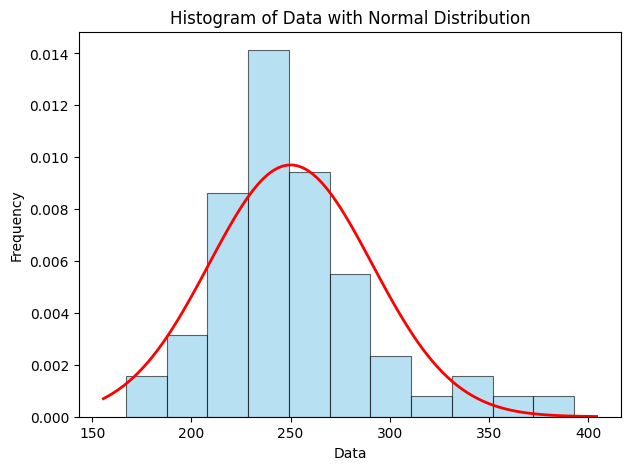

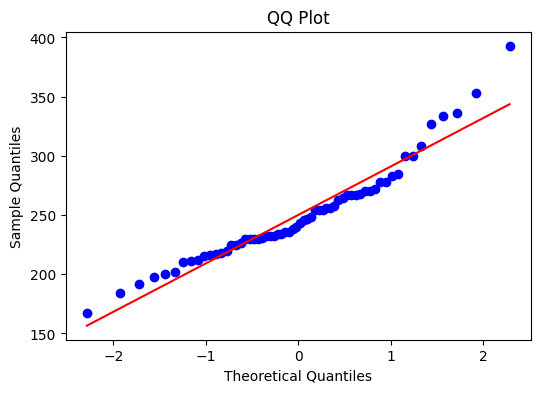

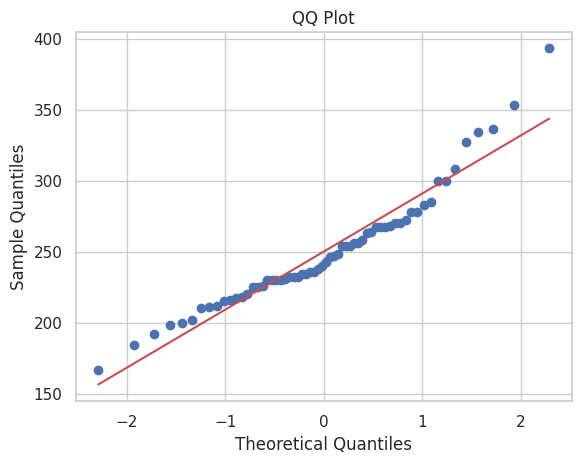

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Data lengkap 62 subjek dari Framingham Heart Study
data = np.array([
    167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230, 230, 230, 230, 231, 232, 232, 232, 234, 234, 236,
    236, 238, 240, 243, 246, 247, 248, 254, 254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285, 300, 300,
    308, 327, 334, 336, 353, 393
])

# 1. Uji Normalitas (Normality Test)
result = stats.normaltest(data)
test_statistic = result.statistic
p_value = result.pvalue

# Menampilkan hasil statistik
print("Test Statistic:", test_statistic)
print("p-value:", p_value)
print("-" * 40)

# 2. Plot Histogram & Kurva Distribusi Normal
plt.figure(figsize=(7, 5))
plt.hist(data, bins='auto', density=True, alpha=0.6, color='skyblue', edgecolor='black', linewidth=0.8)

# Plot kurva distribusi normal
mu, std = np.mean(data), np.std(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
y = stats.norm.pdf(x, mu, std)
plt.plot(x, y, color='red', linewidth=2)

# Mengatur judul dan label grafik
plt.title('Histogram of Data with Normal Distribution')
plt.xlabel('Data')
plt.ylabel('Frequency')
plt.show()

# 3. QQ Plot
plt.figure(figsize=(6, 4))
stats.probplot(data, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()
import numpy as np
import seaborn as sns
import scipy.stats as stats

# Data lengkap 62 subjek dengan kurung penutup yang benar
data = np.array([
    167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230, 230, 230, 230, 231, 232, 232, 232, 234, 234, 236,
    236, 238, 240, 243, 246, 247, 248, 254, 254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285, 300, 300,
    308, 327, 334, 336, 353, 393
])

# Generate QQ plot
sns.set(style="whitegrid")
stats.probplot(data, dist="norm", plot=sns.mpl.pyplot)

# Set plot title and labels
sns.mpl.pyplot.title('QQ Plot')
sns.mpl.pyplot.xlabel('Theoretical Quantiles')
sns.mpl.pyplot.ylabel('Sample Quantiles')

# Show the plot
sns.mpl.pyplot.show()

VISUALISASI PYTHON

In [ ]:
import numpy as np
from scipy import stats

# Data lengkap 62 subjek dengan kurung penutup yang benar
data = np.array([
    167, 184, 192, 198, 200, 202, 210, 211, 212, 215, 216, 217, 218, 220, 225, 225, 226, 230, 230, 230, 230, 231, 232, 232, 232, 234, 234, 236,
    236, 238, 240, 243, 246, 247, 248, 254, 254, 254, 256, 256, 258, 263, 264, 267, 267, 267, 268, 270, 270, 272, 278, 278, 283, 285, 300, 300,
    308, 327, 334, 336, 353, 393
])

# Kolmogorov-Smirnov Test
# Catatan: kstest pada 'norm' idealnya membandingkan data yang sudah distandarisasi (mean=0, std=1),
# namun kode di bawah mengikuti format asli Anda.
ks_statistic, ks_pvalue = stats.kstest(data, 'norm')
print("Kolmogorov-Smirnov Test:")
print("Test Statistic:", ks_statistic)
print("p-value:", ks_pvalue)

# Shapiro-Wilk Test
sw_statistic, sw_pvalue = stats.shapiro(data)
print("\nShapiro-Wilk Test:")
print("Test Statistic:", sw_statistic)
print("p-value:", sw_pvalue)

# Jarque-Bera Test
jb_statistic, jb_pvalue = stats.jarque_bera(data)
print("\nJarque-Bera Test:")
print("Test Statistic:", jb_statistic)
print("p-value:", jb_pvalue)

Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0

Shapiro-Wilk Test:
Test Statistic: 0.9385651298228793
p-value: 0.0038978835421956235

Jarque-Bera Test:
Test Statistic: 17.253454012480432
p-value: 0.00017925037145018067


**Generate random**

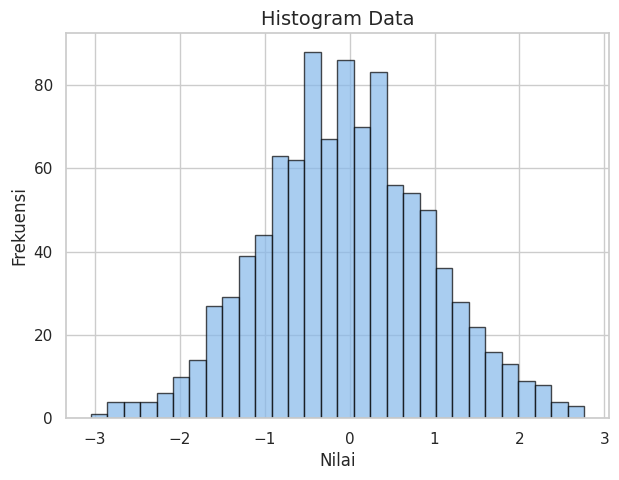

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

#DATA RENDOM
np.random.seed(0)
var1 = np.random.normal(0, 1, 1000)

# Hitung mean dan standar deviasi
mu, sigma = np.mean(var1), np.std(var1)

# Plot histogram
plt.figure(figsize=(7, 5))
count, bins, ignored = plt.hist(var1, bins=30, density=False, color='#85b8eb', edgecolor='black', alpha=0.7)

# Atur judul dan label agar sama persis
plt.title("Histogram Data", fontsize=14)
plt.xlabel("Nilai", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)

# Menampilkan grafik
plt.show()

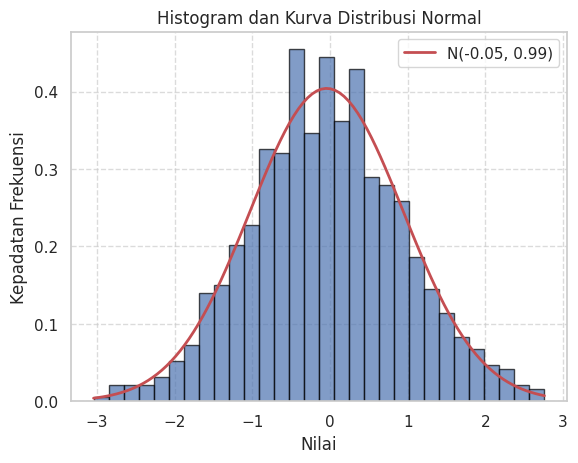

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate random data
np.random.seed(0)
tahun = np.arange(1, 11)
var1 = np.random.normal(0, 1, 1000)  # data lebih banyak agar distribusi normal

# Hitung mean dan standar deviasi
mu, sigma = np.mean(var1), np.std(var1)

# Plot histogram (diperbaiki pada edgecolor)
count, bins, ignored = plt.hist(
    var1, bins=30, density=True, edgecolor='black', alpha=0.7
)

# Plot kurva distribusi normal
x = np.linspace(min(bins), max(bins), 100)
pdf = norm.pdf(x, mu, sigma)  # fungsi kepadatan probabilitas normal
plt.plot(x, pdf, 'r-', linewidth=2, label=f'N({mu:.2f}, {sigma:.2f})')

# Tambahkan label dan grid
plt.xlabel('Nilai')
plt.ylabel('Kepadatan Frekuensi')
plt.title('Histogram dan Kurva Distribusi Normal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

scipy.stats

In [ ]:
import scipy.stats as stats

# Uji normalitas data koding di atas
_, p_value = stats.shapiro(var1)

# Cetak hasil uji normalitas
alpha = 0.05  # Tingkat signifikansi
if p_value > alpha:
    print("Data berdistribusi normal")
else:
    print("Data tidak berdistribusi normal")

Data berdistribusi normal


### **Regresi uji asums Klasik**

In [ ]:
# Regresi uji asums Klasik
import numpy as np
import matplotlib.pyplot as plt

# Generate random data
np.random.seed(0)
tahun = np.arange(1, 11)  # Variabel independen tahun
variabel1 = np.random.normal(0, 1, 10)  # Variabel independen 1
variabel2 = np.random.normal(0, 1, 10)  # Variabel independen 2
nilai_y = 2 * variabel1 + 3 * variabel2 + np.random.normal(0, 1, 10)

# Perform linear regression
X = np.column_stack((variabel1, variabel2))  # Matrix X dengan variabel independen
X = np.column_stack((np.ones(len(tahun)), X))  # Tambahkan kolom untuk intercept
beta = np.linalg.inv(X.T @ X) @ X.T @ nilai_y  # Hitung parameter beta (koefisien)

print("Koefisien Regresi:")
for i in range(len(beta)):
    print(f"Beta{i}: {beta[i]}")

# Plotting data dan regresi
fig, ax = plt.subplots()
ax.scatter(tahun, nilai_y, color='blue', label='Data')
ax.plot(tahun, X @ beta, color='red', label='Regresi')
ax.set_xlabel('Tahun')
ax.set_ylabel('Nilai Y')
ax.legend()

plt.show()

UJI AUTOKORELASI

In [ ]:
# HETEROSKEDASTISITAS: Uji White

import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

# Variabel X dan Y
variabel1 = df["Peng Makanan"]
variabel2 = df["Peng Transportasi"]
nilai_y = df["Berat Badan"]

# Membuat X
X = sm.add_constant(np.column_stack((variabel1, variabel2)))

# Membuat model regresi
model = sm.OLS(nilai_y, X).fit()

# Uji White
white_test = het_white(model.resid, X)

# Mengambil p-value
p_value = white_test[1]

# Tingkat signifikansi
alpha = 0.05

print("=" * 50)
print("HASIL UJI WHITE")
print("=" * 50)
print(f"p-value : {p_value:.4f}")

if p_value > alpha:
    print("Keputusan : Tidak terdapat heteroskedastisitas")
else:
    print("Keputusan : Terdapat heteroskedastisitas")

HASIL UJI WHITE
p-value : 0.3999
Keputusan : Tidak terdapat heteroskedastisitas


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Menyamakan Seed dan Data
np.random.seed(42)
n = 100

# Variabel Independen
X1 = np.random.rand(n) * 10
X2 = 2 * X1 + np.random.normal(0, 1, n)
X3 = np.random.rand(n) * 10

# Variabel Dependen (Y) - Intercept diubah dari 3 menjadi 7
Y = 7 + 2 * X1 + 1.5 * X2 + 0.5 * X3 + np.random.normal(0, 2, n)

# Gabungkan ke dalam DataFrame
df = pd.DataFrame({"Y": Y, "X1": X1, "X2": X2, "X3": X3})

# 2. Estimasi Model Regresi OLS (tanpa print summary)
X = sm.add_constant(df[["X1", "X2", "X3"]])
y = df["Y"]
model = sm.OLS(y, X).fit()

# 3. Uji Multikolinearitas (Variance Inflation Factor / VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) for i in range(X.shape[1])
]

print("=" * 70)
print(" 1. UJI MULTIKOLINEARITAS (VIF)")
print("=" * 70)
print(vif_data)

# 4. Uji Heteroskedastisitas (White Test)
_, p_value_white, _, _ = het_white(model.resid, X)

print("\n" + "=" * 70)
print(" 2. UJI HETEROSKEDASTISITAS (WHITE TEST)")
print("=" * 70)
print(f"p-value White Test: {p_value_white:.6f}")
if p_value_white > 0.05:
  print("Kesimpulan: Tidak ada bukti heteroskedastisitas (Asumsi terpenuhi)")
else:
  print("Kesimpulan: Ada bukti heteroskedastisitas")

 1. UJI MULTIKOLINEARITAS (VIF)
  Variable        VIF
0    const   1.000000
1       X1  42.823796
2       X2  42.798322
3       X3   1.008434

 2. UJI HETEROSKEDASTISITAS (WHITE TEST)
p-value White Test: 0.143789
Kesimpulan: Tidak ada bukti heteroskedastisitas (Asumsi terpenuhi)
